In [2]:
import numpy as np
import torch
import config as C
n=256


In [3]:
device = torch.device("cuda:0"  if torch.cuda.is_available() else "cpu")

In [4]:
#interface samplers -> (pts, dirs) with unit direction e_xi
def _v(n, x, y, device):
    p = torch.rand(n, 2, device=device)
    p[:, 0] = x
    p[:, 1] = p[:, 1] * (y[1] - y[0]) + y[0]
    return p

def _box(n, xmin, xmax, ymin, ymax, device):
    p = torch.rand(n, 2, device=device)
    p[:, 0] = p[:, 0] * (xmax - xmin) + xmin
    p[:, 1] = p[:, 1] * (ymax - ymin) + ymin
    return p

In [5]:
bnd = {}
bnd["left"] = dict(pts=_v(n, 0.0, (0.0, 1.0), device), dom="wall_l")

In [6]:
bnd["right"] = dict(pts=_v(n, 1.0, (0.0, 1.0), device), dom="wall_r")

In [7]:
for side, y in [("top", 1.0), ("bottom", 0.0)]:
        mid = "wall_t" if side == "top" else "wall_b"
        for strip, (x0, x1_) in [("wall_l", (0.0, C.W_IN)),
                                 (mid, (C.W_IN, 1 - C.W_IN)),
                                 ("wall_r", (1 - C.W_IN, 1.0))]:
            bnd[f"{side}_{strip}"] = dict(
                pts=_box(n, x0, x1_, y, y, device), dom=strip,
                dirs=torch.tensor([0.0, 1.0], device=device).expand(n, 2))

In [8]:
bnd

{'left': {'pts': tensor([[0.0000e+00, 5.6538e-01],
          [0.0000e+00, 5.3456e-01],
          [0.0000e+00, 5.0496e-01],
          [0.0000e+00, 7.0909e-01],
          [0.0000e+00, 5.6011e-01],
          [0.0000e+00, 6.4214e-01],
          [0.0000e+00, 3.8851e-01],
          [0.0000e+00, 5.5198e-01],
          [0.0000e+00, 3.6151e-01],
          [0.0000e+00, 9.3254e-03],
          [0.0000e+00, 4.8534e-01],
          [0.0000e+00, 2.4333e-01],
          [0.0000e+00, 4.8008e-01],
          [0.0000e+00, 5.7100e-01],
          [0.0000e+00, 7.6750e-01],
          [0.0000e+00, 3.1973e-01],
          [0.0000e+00, 7.7049e-01],
          [0.0000e+00, 2.8881e-01],
          [0.0000e+00, 7.1591e-01],
          [0.0000e+00, 9.5652e-01],
          [0.0000e+00, 2.3176e-04],
          [0.0000e+00, 3.5026e-01],
          [0.0000e+00, 1.4379e-01],
          [0.0000e+00, 8.4109e-02],
          [0.0000e+00, 6.8917e-01],
          [0.0000e+00, 9.8754e-01],
          [0.0000e+00, 1.3817e-01],
          [0.

In [9]:
_INTERFACES_ALL = [
    ("tbl_wall",        "tbl",    "wall_l"),
    ("wall_air_left",   "wall_l", "air"),
    ("wall_air_right",  "wall_r", "air"),
    ("wall_air_bottom", "wall_b", "air"),
    ("wall_air_top",    "wall_t", "air"),
    ("dev1_wall",       "dev1",   "wall_b"),
    ("dev1_air_left",   "dev1",   "air"),
    ("dev1_air_right",  "dev1",   "air"),
    ("dev1_air_top",    "dev1",   "air"),
    ("dev2_wall",       "dev2",   "wall_t"),
    ("dev2_air_left",   "dev2",   "air"),
    ("dev2_air_right",  "dev2",   "air"),
    ("dev2_air_bottom", "dev2",   "air"),
    ("dev3_air",        "dev3",   "air"),
    # frame corner joints: the four wall strips share edges at the corners
    # (x=0.01/0.99, y in the strip thickness) and must be thermally
    # continuous so heat can flow around the frame
    ("corner_l_b",      "wall_l", "wall_b"),
    ("corner_l_t",      "wall_l", "wall_t"),
    ("corner_r_b",      "wall_r", "wall_b"),
    ("corner_r_t",      "wall_r", "wall_t"),
]
INTERFACES = [t for t in _INTERFACES_ALL
              if not (C.USE_TBL_1D and t[0] == "tbl_wall")]

In [10]:
INTERFACES

[('wall_air_left', 'wall_l', 'air'),
 ('wall_air_right', 'wall_r', 'air'),
 ('wall_air_bottom', 'wall_b', 'air'),
 ('wall_air_top', 'wall_t', 'air'),
 ('dev1_wall', 'dev1', 'wall_b'),
 ('dev1_air_left', 'dev1', 'air'),
 ('dev1_air_right', 'dev1', 'air'),
 ('dev1_air_top', 'dev1', 'air'),
 ('dev2_wall', 'dev2', 'wall_t'),
 ('dev2_air_left', 'dev2', 'air'),
 ('dev2_air_right', 'dev2', 'air'),
 ('dev2_air_bottom', 'dev2', 'air'),
 ('dev3_air', 'dev3', 'air'),
 ('corner_l_b', 'wall_l', 'wall_b'),
 ('corner_l_t', 'wall_l', 'wall_t'),
 ('corner_r_b', 'wall_r', 'wall_b'),
 ('corner_r_t', 'wall_r', 'wall_t')]

In [13]:

def _n_out_tensor(meta, dirs, device):
    if meta["n_out"] == "radial":
        return dirs                      # sampler dirs already point outward
    v = torch.tensor(meta["n_out"], dtype=torch.float32, device=device)
    return v.expand(dirs.shape[0], 2)

In [15]:
import geometry as G
# G.IFACE_META["dev1_wall" ]
n_out = _n_out_tensor(G.IFACE_META["dev1_wall" ], s["dirs"],s["pts"].device)

NameError: name 's' is not defined

In [16]:
DEV_IFACES = {
    "dev1": ["dev1_wall", "dev1_air_left", "dev1_air_right",
             "dev1_air_top"],
    "dev2": ["dev2_wall", "dev2_air_left", "dev2_air_right",
             "dev2_air_bottom"],
    "dev3": ["dev3_air"],
}

In [19]:
for dev,ifaces in DEV_IFACES.items():
    print(dev)
    for iface in ifaces:
        print(iface, G.IFACE_META[iface])

dev1
dev1_wall {'n_out': (0.0, -1.0), 'length': 0.2}
dev1_air_left {'n_out': (-1.0, 0.0), 'length': 0.2}
dev1_air_right {'n_out': (1.0, 0.0), 'length': 0.2}
dev1_air_top {'n_out': (0.0, 1.0), 'length': 0.2}
dev2
dev2_wall {'n_out': (0.0, 1.0), 'length': 0.35}
dev2_air_left {'n_out': (-1.0, 0.0), 'length': 0.35}
dev2_air_right {'n_out': (1.0, 0.0), 'length': 0.35}
dev2_air_bottom {'n_out': (0.0, -1.0), 'length': 0.35}
dev3
dev3_air {'n_out': 'radial', 'length': 0.6283185307179586}


In [26]:
import numpy as np

import matplotlib.pyplot as plt


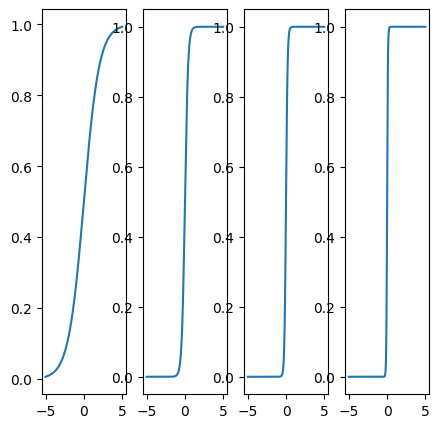

In [38]:
x = np.linspace(-5, 5, 256)

fig,axes =plt.subplots(1,4,figsize=(5,5))
axes[0].plot(x, 1/(1 + np.exp(-1*x)))

axes[1].plot(x, 1/(1 + np.exp(-5*x)))

axes[2].plot(x, 1/(1 + np.exp(-10*x)))
axes[3].plot(x, 1/(1 + np.exp(-20*x)))
plt.show()

In [4]:
import torch
loaded_tensor = torch.load('../checkpoint_m1/center_v4_dirichlet/' + 'latest.pt')

In [6]:
print(loaded_tensor)

{'field': OrderedDict([('center_wall_l', tensor([0.0050, 0.5000], device='cuda:0')), ('scale_wall_l', tensor([0.0050, 0.5000], device='cuda:0')), ('outscale_wall_l', tensor(2., device='cuda:0')), ('center_wall_r', tensor([0.9950, 0.5000], device='cuda:0')), ('scale_wall_r', tensor([0.0050, 0.5000], device='cuda:0')), ('outscale_wall_r', tensor(2., device='cuda:0')), ('center_wall_b', tensor([0.5000, 0.0050], device='cuda:0')), ('scale_wall_b', tensor([0.4900, 0.0050], device='cuda:0')), ('outscale_wall_b', tensor(2., device='cuda:0')), ('center_wall_t', tensor([0.5000, 0.9950], device='cuda:0')), ('scale_wall_t', tensor([0.4900, 0.0050], device='cuda:0')), ('outscale_wall_t', tensor(2., device='cuda:0')), ('center_air', tensor([0.5000, 0.5000], device='cuda:0')), ('scale_air', tensor([0.4900, 0.4900], device='cuda:0')), ('outscale_air', tensor(3., device='cuda:0')), ('center_dev1', tensor([0.5000, 0.1100], device='cuda:0')), ('scale_dev1', tensor([0.5000, 0.1000], device='cuda:0')), ('

In [3]:
import torch
print(torch.version.__version__)

2.3.1+cu118
